In [1]:
import os, sys, warnings, logging, json, time
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Type, Union
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yaml

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal

import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.policies import ActorCriticPolicy
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.callbacks import (
    BaseCallback, EvalCallback, CallbackList
)
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.utils import explained_variance

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
logger = logging.getLogger(__name__)

PROJECT_ROOT = Path('.')
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from environment import CommodityTradingEnv, WalkForwardEnvFactory

MODELS_DIR  = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'
for d in [MODELS_DIR, RESULTS_DIR]:
    d.mkdir(exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch:          {torch.__version__}')

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

C:\Users\anton\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\anton\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\anton\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please 

Device: cuda
PyTorch:          2.6.0+cu124


In [2]:
# ── Load configs ────────────────────────────────────────────────────────────────
with open(PROJECT_ROOT / 'configs' / 'environment.yaml') as f:
    ENV_CONFIG = yaml.safe_load(f)

with open(PROJECT_ROOT / 'configs' / 'features.yaml') as f:
    FEAT_CONFIG = yaml.safe_load(f)

ALL_FEATURES   = FEAT_CONFIG['all_features']   # 40 features
REGIME_FEATURES= FEAT_CONFIG['regime_features'] # 4 regime features
LOOKBACK       = FEAT_CONFIG['lookback_window']  # 60
N_FEATURES     = FEAT_CONFIG['n_features']       # 40

# Indices of regime features within ALL_FEATURES (needed for regime gating)
REGIME_IDX = [ALL_FEATURES.index(f) for f in REGIME_FEATURES]
print(f'Regime feature indices: {REGIME_IDX}')
print(f'Features: {N_FEATURES}, Lookback: {LOOKBACK}')
print(f'Obs dim: {LOOKBACK * N_FEATURES + 5}')

Regime feature indices: [43, 44, 45, 46]
Features: 47, Lookback: 60
Obs dim: 2825


In [3]:
# ── Load data ───────────────────────────────────────────────────────────────────
wti_df = pd.read_parquet(PROJECT_ROOT / 'data' / 'features' / 'WTI_Crude_Oil_features.parquet')
wti_df = wti_df.dropna(subset=ALL_FEATURES + ['log_return', 'close'])

# Walk-forward splits: 3-year train / 1-year test, 1-year step
def make_wf_splits(df, train_years=3, test_years=1):
    dates = df.index.sort_values()
    start = dates[0]
    end   = dates[-1]
    splits = []
    t = start + pd.DateOffset(years=train_years)
    while t + pd.DateOffset(years=test_years) <= end + pd.DateOffset(days=1):
        splits.append({
            'train_start': start,
            'train_end'  : t,
            'test_start' : t,
            'test_end'   : min(t + pd.DateOffset(years=test_years), end + pd.DateOffset(days=1))
        })
        t += pd.DateOffset(years=test_years)
    return splits

WF_SPLITS = make_wf_splits(wti_df)
print(f'Data: {wti_df.index[0].date()} → {wti_df.index[-1].date()}  ({len(wti_df)} rows)')
print(f'Walk-forward splits: {len(WF_SPLITS)}')
for i, s in enumerate(WF_SPLITS):
    print(f'  Split {i}: train {s["train_start"].date()}–{s["train_end"].date()} | '
          f'test {s["test_start"].date()}–{s["test_end"].date()}')

Data: 2005-12-21 → 2024-12-31  (4965 rows)
Walk-forward splits: 16
  Split 0: train 2005-12-21–2008-12-21 | test 2008-12-21–2009-12-21
  Split 1: train 2005-12-21–2009-12-21 | test 2009-12-21–2010-12-21
  Split 2: train 2005-12-21–2010-12-21 | test 2010-12-21–2011-12-21
  Split 3: train 2005-12-21–2011-12-21 | test 2011-12-21–2012-12-21
  Split 4: train 2005-12-21–2012-12-21 | test 2012-12-21–2013-12-21
  Split 5: train 2005-12-21–2013-12-21 | test 2013-12-21–2014-12-21
  Split 6: train 2005-12-21–2014-12-21 | test 2014-12-21–2015-12-21
  Split 7: train 2005-12-21–2015-12-21 | test 2015-12-21–2016-12-21
  Split 8: train 2005-12-21–2016-12-21 | test 2016-12-21–2017-12-21
  Split 9: train 2005-12-21–2017-12-21 | test 2017-12-21–2018-12-21
  Split 10: train 2005-12-21–2018-12-21 | test 2018-12-21–2019-12-21
  Split 11: train 2005-12-21–2019-12-21 | test 2019-12-21–2020-12-21
  Split 12: train 2005-12-21–2020-12-21 | test 2020-12-21–2021-12-21
  Split 13: train 2005-12-21–2021-12-21 | test

In [4]:
class RegimeGatingLayer(nn.Module):
    """Learns to gate latent features based on 4 regime signals."""

    def __init__(self, n_regime: int, latent_dim: int):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(n_regime, latent_dim * 2),
            nn.Tanh(),
            nn.Linear(latent_dim * 2, latent_dim),
            nn.Sigmoid(),          # γ ∈ (0,1)^d
        )
        # Initialise close to 1 so early training is close to unregularised PPO
        nn.init.zeros_(self.gate[-2].bias)
        nn.init.zeros_(self.gate[-2].weight)

    def forward(self, regime_signals: torch.Tensor, latent: torch.Tensor) -> torch.Tensor:
        gamma = self.gate(regime_signals)          # (B, latent_dim)
        # Bias toward 1: γ' = 0.5·γ + 0.5  ∈ (0.5, 1)
        gamma = 0.5 * gamma + 0.5
        return latent * gamma


class ResidualBlock(nn.Module):
    """Pre-norm residual block: LayerNorm → Linear → Activation → Linear + skip."""

    def __init__(self, dim: int, dropout: float = 0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.block(x)


class RegimeAwareExtractor(BaseFeaturesExtractor):
    """
    Custom SB3 feature extractor for ARA-PPO.

    Architecture
    ─────────────
    1. Flatten raw observation
    2. Main trunk: Linear(obs) → ResidualBlock × 2  → latent ∈ R^256
    3. Regime trunk: reads regime features → gating γ ∈ (0.5,1)^256
    4. Gated latent: z = latent * γ
    5. Return (z, regime_signals) packed into a flat vector
       SB3 expects a flat tensor; we cat z ‖ regime_signals.
    """

    # Indices of the 4 regime features inside the LAST lookback step
    # The obs layout is: feat_window.flatten() ‖ port_state (5)
    # feat_window[lookback-1, :] starts at index (lookback-1)*n_features

    def __init__(
        self,
        observation_space: gym.Space,
        latent_dim: int = 256,
        n_regime: int = 4,
        lookback: int = 60,
        n_features: int = 40,
        regime_idx: List[int] = None,
        dropout: float = 0.1,
    ):
        # features_dim is what SB3 passes to actor/critic heads
        features_dim = latent_dim + n_regime
        super().__init__(observation_space, features_dim=features_dim)

        self.latent_dim   = latent_dim
        self.n_regime     = n_regime
        self.lookback     = lookback
        self.n_features   = n_features
        # Offset to last-step features in flattened obs
        self._last_step_offset = (lookback - 1) * n_features
        self._regime_idx = regime_idx if regime_idx is not None else list(range(n_regime))

        obs_dim = int(np.prod(observation_space.shape))

        # ── Main trunk ────────────────────────────────────────────────────────────
        self.input_proj = nn.Sequential(
            nn.Linear(obs_dim, latent_dim),
            nn.LayerNorm(latent_dim),
            nn.ELU(),
        )
        self.res_blocks = nn.Sequential(
            ResidualBlock(latent_dim, dropout),
            ResidualBlock(latent_dim, dropout),
        )
        self.post_norm = nn.LayerNorm(latent_dim)

        # ── Regime trunk & gating ─────────────────────────────────────────────────
        self.regime_gating = RegimeGatingLayer(n_regime, latent_dim)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)

    def _extract_regime(self, obs: torch.Tensor) -> torch.Tensor:
        """Extract the 4 regime features from the most-recent timestep."""
        regime_vals = []
        for ri in self._regime_idx:
            col_idx = self._last_step_offset + ri
            regime_vals.append(obs[:, col_idx:col_idx+1])
        return torch.cat(regime_vals, dim=-1)   # (B, 4)

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        regime_signals = self._extract_regime(observations)
        z = self.input_proj(observations)
        z = self.res_blocks(z)
        z = self.post_norm(z)
        z = self.regime_gating(regime_signals, z)         # gated latent
        return torch.cat([z, regime_signals], dim=-1)     # (B, latent+4)


# ── Quick sanity check ─────────────────────────────────────────────────────────
obs_dim = LOOKBACK * N_FEATURES + 5
_dummy_space = gym.spaces.Box(-5, 5, shape=(obs_dim,), dtype=np.float32)
_extractor = RegimeAwareExtractor(
    _dummy_space,
    latent_dim=256, n_regime=4,
    lookback=LOOKBACK, n_features=N_FEATURES,
    regime_idx=REGIME_IDX
)
_x = torch.zeros(4, obs_dim)
_out = _extractor(_x)
print(f'Extractor output shape: {_out.shape}  (expected: [4, 260])')
assert _out.shape == (4, 260), f'Got {_out.shape}'
n_params = sum(p.numel() for p in _extractor.parameters())
print(f'Extractor parameters: {n_params:,}')

Extractor output shape: torch.Size([4, 260])  (expected: [4, 260])
Extractor parameters: 1,122,560


In [5]:
class AdaptiveClipCallback(BaseCallback):
    """
    Modification 2: Adapt PPO clip_range based on regime_vol.

    At each rollout, reads regime_vol from the collected observations
    and adjusts clip_range for the next update.

    Parameters
    ----------
    eps_base   : float  – baseline clip value (default 0.2)
    alpha      : float  – sensitivity to regime_vol (default 0.5)
    eps_min    : float  – floor (default 0.05)
    eps_max    : float  – ceiling (default 0.4)
    regime_obs_idx : int – position of regime_vol in the flattened observation
    """

    def __init__(
        self,
        eps_base: float = 0.2,
        alpha: float = 0.5,
        eps_min: float = 0.05,
        eps_max: float = 0.40,
        regime_obs_idx: int = None,
        verbose: int = 0,
    ):
        super().__init__(verbose)
        self.eps_base       = eps_base
        self.alpha          = alpha
        self.eps_min        = eps_min
        self.eps_max        = eps_max
        self.regime_obs_idx = regime_obs_idx  # set externally if known
        self.clip_history   = []

    def _on_rollout_end(self) -> bool:
        """Called after rollout buffer is filled, before policy update."""
        # Read regime_vol from rollout buffer observations
        obs = self.model.rollout_buffer.observations   # (n_steps, n_envs, obs_dim)
        if self.regime_obs_idx is not None and obs is not None:
            regime_vol = obs[:, :, self.regime_obs_idx].mean()  # scalar
        else:
            # Fall-back: use last-step regime feature from extractor if available
            regime_vol = 0.0

        # Normalise: regime_vol is RobustScaler output, typically in [-5,5]
        # Map to [0,1] via sigmoid
        regime_vol_norm = float(torch.sigmoid(torch.tensor(float(regime_vol))).item())

        new_eps = self.eps_base * (1.0 + self.alpha * regime_vol_norm)
        new_eps = float(np.clip(new_eps, self.eps_min, self.eps_max))

        # SB3 clip_range is a callable; wrap scalar in a lambda
        self.model.clip_range = lambda _: new_eps
        self.clip_history.append(new_eps)

        if self.verbose >= 2:
            logger.info(f'AdaptiveClip: regime_vol={regime_vol:.3f} → ε={new_eps:.4f}')
        return True

    def _on_step(self) -> bool:
        return True


print('AdaptiveClipCallback defined.')
print('  Clip range schedule: ε = ε_base × (1 + α·σ(regime_vol))')
print('  Bounds: [ε_min=0.05, ε_max=0.40]')

AdaptiveClipCallback defined.
  Clip range schedule: ε = ε_base × (1 + α·σ(regime_vol))
  Bounds: [ε_min=0.05, ε_max=0.40]


In [6]:
class RegimeDecomposedValueNet(nn.Module):
    """
    Modification 3: V(s) = V_base(s) + alpha_regime * V_regime(s)

    Installed as policy.value_net by ARAPPOPolicy._build().
    Input: full feature vector from extractor (latent + regime signals).
    """

    def __init__(self, features_dim: int, n_regime: int = 4, hidden: int = 128):
        super().__init__()
        self.v_base = nn.Sequential(
            nn.Linear(features_dim, hidden), nn.ELU(),
            nn.Linear(hidden, hidden // 2), nn.ELU(),
            nn.Linear(hidden // 2, 1),
        )
        self.v_regime = nn.Sequential(
            nn.Linear(n_regime, hidden // 2), nn.Tanh(),
            nn.Linear(hidden // 2, hidden // 4), nn.Tanh(),
            nn.Linear(hidden // 4, 1),
        )
        self.alpha_regime = nn.Parameter(torch.tensor(0.1))
        self.n_regime = n_regime
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        regime_signals = features[:, -self.n_regime:]
        alpha = torch.clamp(self.alpha_regime, 0.0, 1.0)
        return self.v_base(features) + alpha * self.v_regime(regime_signals)


class _ARAMlpExtractorWrapper(nn.Module):
    """
    Wraps actor body + critic pass-through for SB3's ActorCriticPolicy.

    Actor path  : features -> actor_body -> latent_pi (size actor_hidden//2)
                  SB3 action_net = Linear(latent_pi, action_dim)
    Critic path : features -> pass-through (latent_vf = features_dim)
                  ARAPPOPolicy._build() replaces value_net with RegimeDecomposedValueNet
    """

    def __init__(self, features_dim: int, n_regime: int, actor_hidden: int):
        super().__init__()
        self.actor_body = nn.Sequential(
            nn.Linear(features_dim, actor_hidden), nn.ELU(),
            nn.Linear(actor_hidden, actor_hidden // 2), nn.ELU(),
        )
        self.latent_dim_pi = actor_hidden // 2  # SB3 sizes action_net from this
        self.latent_dim_vf = features_dim        # pass-through; replaced value_net reads this
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)

    def forward(self, features: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.actor_body(features), features

    def forward_actor(self, features: torch.Tensor) -> torch.Tensor:
        return self.actor_body(features)

    def forward_critic(self, features: torch.Tensor) -> torch.Tensor:
        return features   # RegimeDecomposedValueNet is installed as value_net


# ── Sanity check ─────────────────────────────────────────────────────────────────
features_dim = 260
_vnet    = RegimeDecomposedValueNet(features_dim, n_regime=4)
_wrapper = _ARAMlpExtractorWrapper(features_dim, n_regime=4, actor_hidden=128)
_feat    = torch.randn(8, features_dim)
_pi, _vf = _wrapper(_feat)
print(f'pi_latent shape  : {_pi.shape}   (expected [8, 64])')
print(f'vf_features shape: {_vf.shape}  (expected [8, 260])')
print(f'Value net output : {_vnet(_vf).shape}  (expected [8, 1])')
print(f'alpha_regime init: {_vnet.alpha_regime.item():.4f}')
assert _pi.shape == (8, 64) and _vf.shape == (8, 260) and _vnet(_vf).shape == (8, 1)


pi_latent shape  : torch.Size([8, 64])   (expected [8, 64])
vf_features shape: torch.Size([8, 260])  (expected [8, 260])
Value net output : torch.Size([8, 1])  (expected [8, 1])
alpha_regime init: 0.1000


In [7]:
class ARAPPOPolicy(ActorCriticPolicy):
    """
    Full ARA-PPO policy wiring all three modifications:

      Mod 1  -- RegimeAwareExtractor (features_extractor)
      Mod 2  -- AdaptiveClipCallback (wired externally)
      Mod 3  -- RegimeDecomposedValueNet injected as value_net in _build()

    Override strategy:
      _build_mlp_extractor  : installs _ARAMlpExtractorWrapper
      _build                : calls super() then replaces value_net with Mod 3
    """

    def __init__(
        self,
        observation_space,
        action_space,
        lr_schedule,
        latent_dim: int = 256,
        n_regime: int = 4,
        lookback: int = 60,
        n_features: int = 40,
        regime_idx: List[int] = None,
        actor_hidden: int = 128,
        critic_hidden: int = 128,
        dropout: float = 0.1,
        **kwargs,
    ):
        self._ara_latent_dim  = latent_dim
        self._ara_n_regime    = n_regime
        self._ara_actor_h     = actor_hidden
        self._ara_critic_h    = critic_hidden

        kwargs['features_extractor_class']  = RegimeAwareExtractor
        kwargs['features_extractor_kwargs'] = dict(
            latent_dim  = latent_dim,
            n_regime    = n_regime,
            lookback    = lookback,
            n_features  = n_features,
            regime_idx  = regime_idx if regime_idx is not None else list(range(n_regime)),
            dropout     = dropout,
        )
        kwargs['net_arch'] = dict(pi=[], vf=[])
        super().__init__(observation_space, action_space, lr_schedule, **kwargs)

    def _build_mlp_extractor(self) -> None:
        fd = self._ara_latent_dim + self._ara_n_regime
        self.mlp_extractor = _ARAMlpExtractorWrapper(
            features_dim  = fd,
            n_regime      = self._ara_n_regime,
            actor_hidden  = self._ara_actor_h,
        )

    def _build(self, lr_schedule) -> None:
        """
        Call SB3's _build() to set up action_net / log_std / optimizer,
        then replace value_net with RegimeDecomposedValueNet (Mod 3).
        """
        super()._build(lr_schedule)
        fd = self._ara_latent_dim + self._ara_n_regime
        # Replace SB3's Linear(features_dim, 1) with Mod 3 decomposed value net
        self.value_net = RegimeDecomposedValueNet(
            features_dim = fd,
            n_regime     = self._ara_n_regime,
            hidden       = self._ara_critic_h,
        )


print('ARAPPOPolicy defined.')
print('  _build_mlp_extractor -> _ARAMlpExtractorWrapper')
print('  _build               -> super() + replaces value_net with RegimeDecomposedValueNet')


ARAPPOPolicy defined.
  _build_mlp_extractor -> _ARAMlpExtractorWrapper
  _build               -> super() + replaces value_net with RegimeDecomposedValueNet


In [8]:
# ── Hyperparameters ─────────────────────────────────────────────────────────────
ARA_PPO_HPARAMS = {
    # PPO core
    'learning_rate'    : 3e-4,
    'n_steps'          : 2048,
    'batch_size'       : 256,
    'n_epochs'         : 10,
    'gamma'            : 0.99,
    'gae_lambda'       : 0.95,
    'clip_range'       : 0.2,          # baseline; adapted by AdaptiveClipCallback
    'clip_range_vf'    : None,
    'normalize_advantage': True,
    'ent_coef'         : 0.01,
    'vf_coef'          : 0.5,
    'max_grad_norm'    : 0.5,
    # Architecture
    'latent_dim'       : 256,
    'n_regime'         : 4,
    'actor_hidden'     : 128,
    'critic_hidden'    : 128,
    'dropout'          : 0.1,
    # Adaptive clip
    'eps_base'         : 0.2,
    'eps_alpha'        : 0.5,
    'eps_min'          : 0.05,
    'eps_max'          : 0.40,
}


def make_ara_ppo(
    env: gym.Env,
    hparams: dict = None,
    lookback: int = LOOKBACK,
    n_features: int = N_FEATURES,
    regime_idx: List[int] = None,
    seed: int = SEED,
    verbose: int = 0,
) -> Tuple[PPO, AdaptiveClipCallback]:
    """
    Build a fully configured ARA-PPO model.

    Returns
    -------
    model    : SB3 PPO instance with ARAPPOPolicy
    callback : AdaptiveClipCallback (to be passed to model.learn)
    """
    hp = {**ARA_PPO_HPARAMS, **(hparams or {})}
    ri = regime_idx if regime_idx is not None else REGIME_IDX

    # The regime_vol feature index inside the flat observation vector
    # = (lookback-1)*n_features + regime_vol_position_in_features
    regime_vol_feat_pos = ALL_FEATURES.index('regime_vol')
    regime_obs_idx = (lookback - 1) * n_features + regime_vol_feat_pos

    policy_kwargs = dict(
        latent_dim    = hp['latent_dim'],
        n_regime      = hp['n_regime'],
        lookback      = lookback,
        n_features    = n_features,
        regime_idx    = ri,
        actor_hidden  = hp['actor_hidden'],
        critic_hidden = hp['critic_hidden'],
        dropout       = hp['dropout'],
    )

    vec_env = DummyVecEnv([lambda: env])

    model = PPO(
        policy             = ARAPPOPolicy,
        env                = vec_env,
        learning_rate      = hp['learning_rate'],
        n_steps            = hp['n_steps'],
        batch_size         = hp['batch_size'],
        n_epochs           = hp['n_epochs'],
        gamma              = hp['gamma'],
        gae_lambda         = hp['gae_lambda'],
        clip_range         = hp['clip_range'],
        clip_range_vf      = hp['clip_range_vf'],
        normalize_advantage= hp['normalize_advantage'],
        ent_coef           = hp['ent_coef'],
        vf_coef            = hp['vf_coef'],
        max_grad_norm      = hp['max_grad_norm'],
        policy_kwargs      = policy_kwargs,
        seed               = seed,
        device             = DEVICE,
        verbose            = verbose,
    )

    clip_cb = AdaptiveClipCallback(
        eps_base       = hp['eps_base'],
        alpha          = hp['eps_alpha'],
        eps_min        = hp['eps_min'],
        eps_max        = hp['eps_max'],
        regime_obs_idx = regime_obs_idx,
        verbose        = verbose,
    )

    return model, clip_cb


print('make_ara_ppo() factory defined.')

make_ara_ppo() factory defined.


In [9]:
class EpisodeMetricsCallback(BaseCallback):
    """
    Collects per-episode metrics from the info dict and logs them to TensorBoard.
    Also maintains running lists for later plotting.
    """

    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_sharpes  = []
        self.episode_returns  = []
        self.episode_drawdowns= []
        self._ep_reward       = 0.0
        self._ep_steps        = 0

    def _on_step(self) -> bool:
        self._ep_reward += float(self.locals['rewards'][0])
        self._ep_steps  += 1

        dones = self.locals.get('dones', [False])
        infos = self.locals.get('infos', [{}])
        if dones[0]:
            info = infos[0]
            sharpe  = info.get('sharpe', 0.0)
            ret     = info.get('total_return', 0.0)
            dd      = info.get('drawdown', 0.0)
            self.episode_sharpes.append(sharpe)
            self.episode_returns.append(ret)
            self.episode_drawdowns.append(dd)
            self.logger.record('episode/sharpe',   sharpe)
            self.logger.record('episode/return',   ret)
            self.logger.record('episode/drawdown', dd)
            self.logger.record('episode/reward',   self._ep_reward)
            self._ep_reward = 0.0
            self._ep_steps  = 0
        return True


class RegimeAlphaCallback(BaseCallback):
    """
    Logs the learnable alpha_regime from the value decomposition (Mod 3)
    and the current adaptive clip range (Mod 2).
    """

    def __init__(self, clip_callback: AdaptiveClipCallback, log_freq: int = 1000, verbose=0):
        super().__init__(verbose)
        self.clip_cb    = clip_callback
        self.log_freq   = log_freq
        self.alpha_hist = []

    def _on_step(self) -> bool:
        if self.n_calls % self.log_freq == 0:
            try:
                alpha = self.model.policy.value_net.alpha_regime.item()
                alpha = float(np.clip(alpha, 0, 1))
                self.alpha_hist.append(alpha)
                self.logger.record('ara/alpha_regime', alpha)
                if self.clip_cb.clip_history:
                    self.logger.record('ara/clip_range', self.clip_cb.clip_history[-1])
            except AttributeError:
                pass
        return True


class EarlyStoppingCallback(BaseCallback):
    """
    Stop training when rolling mean Sharpe (over last `window` episodes)
    does not improve by `min_delta` for `patience` consecutive checks.
    """

    def __init__(
        self,
        metrics_cb: EpisodeMetricsCallback,
        patience: int = 20,
        window: int = 10,
        min_delta: float = 0.01,
        check_freq: int = 5000,
        verbose: int = 1,
    ):
        super().__init__(verbose)
        self.metrics_cb  = metrics_cb
        self.patience    = patience
        self.window      = window
        self.min_delta   = min_delta
        self.check_freq  = check_freq
        self._best       = -np.inf
        self._no_improve = 0

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq != 0:
            return True
        sharpes = self.metrics_cb.episode_sharpes
        if len(sharpes) < self.window:
            return True
        current = float(np.mean(sharpes[-self.window:]))
        if current > self._best + self.min_delta:
            self._best       = current
            self._no_improve = 0
            if self.verbose:
                logger.info(f'EarlyStopping: new best Sharpe={current:.4f}')
        else:
            self._no_improve += 1
            if self.verbose:
                logger.info(f'EarlyStopping: no improve {self._no_improve}/{self.patience}, '
                            f'Sharpe={current:.4f}')
        if self._no_improve >= self.patience:
            if self.verbose:
                logger.info('EarlyStopping triggered — halting training.')
            return False   # signal SB3 to stop
        return True


print('Callbacks defined: EpisodeMetricsCallback, RegimeAlphaCallback, EarlyStoppingCallback')

Callbacks defined: EpisodeMetricsCallback, RegimeAlphaCallback, EarlyStoppingCallback


In [10]:
# Build a small train env for verification
train_df = wti_df.iloc[:1000].copy()
_env = CommodityTradingEnv(train_df, ALL_FEATURES, ENV_CONFIG, mode='train')

# Instantiate ARA-PPO on the small verification env
model, clip_cb = make_ara_ppo(_env, verbose=0)

# Architecture summary
policy      = model.policy
extractor   = policy.features_extractor
mlp_wrapper = policy.mlp_extractor
actor_body  = mlp_wrapper.actor_body
value_net   = policy.value_net

def count_params(module):
    return sum(p.numel() for p in module.parameters())

print('='*58)
print('           ARA-PPO Architecture Summary')
print('='*58)
print(f'  Feature Extractor (Mod 1 - Regime Gating)  : {count_params(extractor):>10,}')
print(f'    Main trunk (input_proj + res_blocks)      : {count_params(extractor.input_proj) + count_params(extractor.res_blocks):>10,}')
print(f'    Regime gating layer                       : {count_params(extractor.regime_gating):>10,}')
n_actor = count_params(actor_body) + count_params(policy.action_net)
print(f'  Actor (body + action_net)                   : {n_actor:>10,}')
n_critic = count_params(value_net)
alpha_i  = float(value_net.alpha_regime.item())
print(f'  Critic - Mod 3 Value Decomp                 : {n_critic:>10,}  (alpha_regime={alpha_i:.4f})')
print('-'*58)
print(f'  TOTAL trainable parameters                  : {count_params(policy):>10,}')
print('='*58)

# Forward-pass test
obs, _ = _env.reset(seed=0)
obs_t  = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    feat = policy.extract_features(obs_t)
    pi_h = mlp_wrapper.forward_actor(feat)
    mu   = policy.action_net(pi_h)
    val  = value_net(feat)

print(f'\nForward pass:')
print(f'  obs shape    : {obs_t.shape}')
print(f'  features dim : {feat.shape}')
print(f'  pi_latent    : {pi_h.shape}')
print(f'  action mu    : {mu.item():.4f}')
print(f'  V(s)         : {val.item():.4f}')

print(f'\nMod 2 - AdaptiveClipCallback:')
print(f'  regime_obs_idx = {clip_cb.regime_obs_idx}')
print(f'  eps_base={clip_cb.eps_base}, alpha={clip_cb.alpha}, bounds=[{clip_cb.eps_min},{clip_cb.eps_max}]')

           ARA-PPO Architecture Summary
  Feature Extractor (Mod 1 - Regime Gating)  :  1,122,560
    Main trunk (input_proj + res_blocks)      :    988,160
    Regime gating layer                       :    133,888
  Actor (body + action_net)                   :     41,729
  Critic - Mod 3 Value Decomp                 :     44,163  (alpha_regime=0.1000)
----------------------------------------------------------
  TOTAL trainable parameters                  :  1,208,453

Forward pass:
  obs shape    : torch.Size([1, 2825])
  features dim : torch.Size([1, 260])
  pi_latent    : torch.Size([1, 64])
  action mu    : -0.0025
  V(s)         : -0.3504

Mod 2 - AdaptiveClipCallback:
  regime_obs_idx = 2816
  eps_base=0.2, alpha=0.5, bounds=[0.05,0.4]


In [11]:
# ── Walk-forward split 0 ──────────────────────────────────────────────────────
wf_factory = WalkForwardEnvFactory(wti_df, ALL_FEATURES, WF_SPLITS, ENV_CONFIG)
train_env0, test_env0, scaler0 = wf_factory.get_split(0)

assert train_env0 is not None, 'Split 0 returned None train env'
print(f'Split 0 — train rows: {len(train_env0.df)}, test rows: {len(test_env0.df)}')

# ── Build model ───────────────────────────────────────────────────────────────
model0, clip_cb0 = make_ara_ppo(
    train_env0,
    hparams={'n_steps': 512, 'batch_size': 64},
    verbose=0
)

# ── Callbacks ─────────────────────────────────────────────────────────────────
ep_cb0    = EpisodeMetricsCallback(verbose=0)
alpha_cb0 = RegimeAlphaCallback(clip_cb0, log_freq=500)
early_cb0 = EarlyStoppingCallback(ep_cb0, patience=15, check_freq=2000, verbose=1)
callbacks = CallbackList([clip_cb0, ep_cb0, alpha_cb0, early_cb0])

# ── Train ─────────────────────────────────────────────────────────────────────
PILOT_STEPS = 50_000
print(f'\nTraining ARA-PPO for {PILOT_STEPS:,} steps...')
t0 = time.time()

model0.learn(
    total_timesteps = PILOT_STEPS,
    callback        = callbacks,
    progress_bar    = True,
)

elapsed = time.time() - t0
print(f'\nTraining complete in {elapsed:.1f}s  ({PILOT_STEPS/elapsed:.0f} steps/sec)')

Split 0 — train rows: 783, test rows: 260

Training ARA-PPO for 50,000 steps...


2026-04-16 17:55:47,391 [INFO] EarlyStopping: new best Sharpe=0.0172
2026-04-16 17:56:00,489 [INFO] EarlyStopping: no improve 1/15, Sharpe=-0.6279
2026-04-16 17:56:13,338 [INFO] EarlyStopping: no improve 2/15, Sharpe=-0.9829
2026-04-16 17:56:26,149 [INFO] EarlyStopping: no improve 3/15, Sharpe=-0.8161
2026-04-16 17:56:39,325 [INFO] EarlyStopping: no improve 4/15, Sharpe=-0.8548
2026-04-16 17:56:52,693 [INFO] EarlyStopping: no improve 5/15, Sharpe=-0.1114
2026-04-16 17:57:05,783 [INFO] EarlyStopping: no improve 6/15, Sharpe=-0.4551
2026-04-16 17:57:18,515 [INFO] EarlyStopping: no improve 7/15, Sharpe=-0.5128
2026-04-16 17:57:31,277 [INFO] EarlyStopping: no improve 8/15, Sharpe=-0.8338
2026-04-16 17:57:43,169 [INFO] EarlyStopping: no improve 9/15, Sharpe=-0.8461
2026-04-16 17:57:56,215 [INFO] EarlyStopping: no improve 10/15, Sharpe=-0.8268
2026-04-16 17:58:08,869 [INFO] EarlyStopping: no improve 11/15, Sharpe=-0.6759
2026-04-16 17:58:21,651 [INFO] EarlyStopping: no improve 12/15, Sharpe=


Training complete in 219.1s  (228 steps/sec)


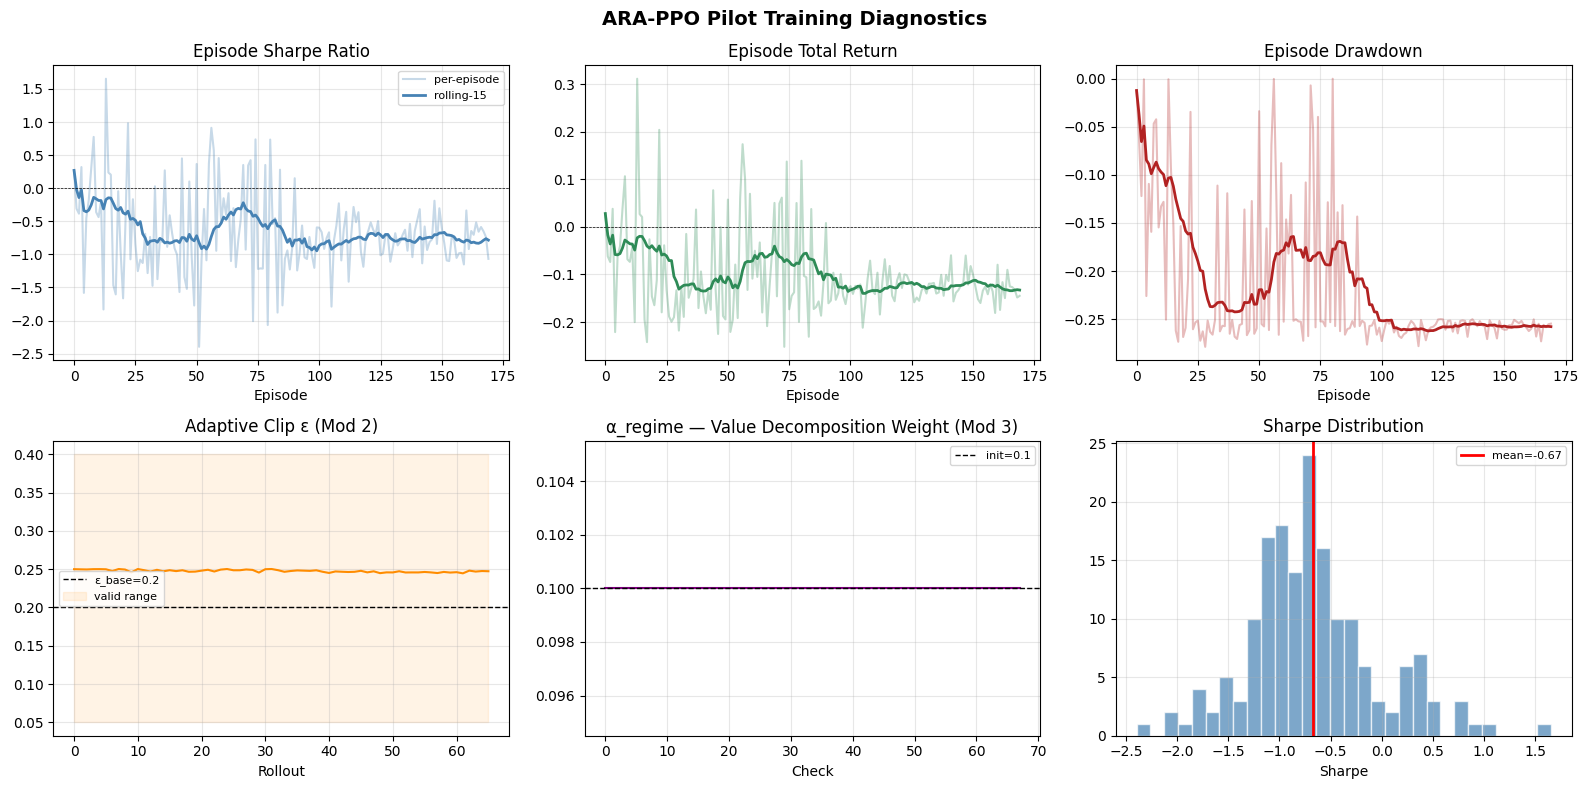


Pilot Training Summary
────────────────────────────────────────
  Episodes completed   : 170
  Mean Sharpe          : -0.6696
  Last-20 Sharpe       : -0.8062
  Mean Return          : -0.1036
  Final ε              : 0.2472
  Final α_regime       : 0.1000


In [12]:
# ── Training diagnostics ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('ARA-PPO Pilot Training Diagnostics', fontsize=14, fontweight='bold')

def smooth(x, w=10):
    if len(x) < w:
        return np.array(x)
    return pd.Series(x).rolling(w, min_periods=1).mean().values

# 1. Episode Sharpe
ax = axes[0, 0]
sharpes = ep_cb0.episode_sharpes
if sharpes:
    ax.plot(sharpes, alpha=0.3, color='steelblue', label='per-episode')
    ax.plot(smooth(sharpes, 15), color='steelblue', linewidth=2, label='rolling-15')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Episode Sharpe Ratio')
ax.set_xlabel('Episode')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 2. Episode Return
ax = axes[0, 1]
rets = ep_cb0.episode_returns
if rets:
    ax.plot(rets, alpha=0.3, color='seagreen')
    ax.plot(smooth(rets, 15), color='seagreen', linewidth=2)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Episode Total Return')
ax.set_xlabel('Episode')
ax.grid(True, alpha=0.3)

# 3. Episode Max Drawdown
ax = axes[0, 2]
dds = ep_cb0.episode_drawdowns
if dds:
    ax.plot(dds, alpha=0.3, color='firebrick')
    ax.plot(smooth(dds, 15), color='firebrick', linewidth=2)
ax.set_title('Episode Drawdown')
ax.set_xlabel('Episode')
ax.grid(True, alpha=0.3)

# 4. Adaptive clip range (Mod 2)
ax = axes[1, 0]
if clip_cb0.clip_history:
    ax.plot(clip_cb0.clip_history, color='darkorange', linewidth=1.5)
    ax.axhline(ARA_PPO_HPARAMS['eps_base'], color='black', linewidth=1, linestyle='--',
               label=f'ε_base={ARA_PPO_HPARAMS["eps_base"]}')
    ax.fill_between(range(len(clip_cb0.clip_history)),
                    ARA_PPO_HPARAMS['eps_min'], ARA_PPO_HPARAMS['eps_max'],
                    alpha=0.1, color='darkorange', label='valid range')
ax.set_title('Adaptive Clip ε (Mod 2)')
ax.set_xlabel('Rollout')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 5. alpha_regime evolution (Mod 3)
ax = axes[1, 1]
if alpha_cb0.alpha_hist:
    ax.plot(alpha_cb0.alpha_hist, color='purple', linewidth=1.5)
    ax.axhline(0.1, color='black', linewidth=1, linestyle='--', label='init=0.1')
ax.set_title('α_regime — Value Decomposition Weight (Mod 3)')
ax.set_xlabel('Check')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 6. Sharpe distribution
ax = axes[1, 2]
if len(sharpes) > 5:
    ax.hist(sharpes, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(np.mean(sharpes), color='red', linewidth=2, label=f'mean={np.mean(sharpes):.2f}')
ax.set_title('Sharpe Distribution')
ax.set_xlabel('Sharpe')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ara_ppo_pilot_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary stats ────────────────────────────────────────────────────────────────
print('\nPilot Training Summary')
print('─' * 40)
if sharpes:
    print(f'  Episodes completed   : {len(sharpes)}')
    print(f'  Mean Sharpe          : {np.mean(sharpes):.4f}')
    print(f'  Last-20 Sharpe       : {np.mean(sharpes[-20:]):.4f}')
if rets:
    print(f'  Mean Return          : {np.mean(rets):.4f}')
if clip_cb0.clip_history:
    print(f'  Final ε              : {clip_cb0.clip_history[-1]:.4f}')
if alpha_cb0.alpha_hist:
    print(f'  Final α_regime       : {alpha_cb0.alpha_hist[-1]:.4f}')

In [13]:
def evaluate_model(model: PPO, env: CommodityTradingEnv, n_episodes: int = 5, seed: int = 0) -> Dict:
    """
    Run `n_episodes` full episodes using deterministic policy actions.
    Returns aggregated metrics.
    """
    all_metrics = []
    all_values  = []
    all_actions = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, _, terminated, truncated, info = env.step(action)
            done = terminated or truncated
        m = env.get_episode_metrics()
        all_metrics.append(m)
        all_values.append(env.value_history.copy())
        all_actions.append(env.action_history.copy())

    keys = all_metrics[0].keys()
    agg  = {k: np.mean([m[k] for m in all_metrics]) for k in keys}
    agg['value_curves'] = all_values
    agg['action_curves']= all_actions
    return agg


print('Evaluating on split-0 test set...')
eval_metrics = evaluate_model(model0, test_env0, n_episodes=3, seed=42)

print('\n── Test Evaluation (Split 0) ─────────────────────────')
for k, v in eval_metrics.items():
    if not isinstance(v, list):
        print(f'  {k:<22}: {v:>10.4f}')

Evaluating on split-0 test set...

── Test Evaluation (Split 0) ─────────────────────────
  total_return          :    -0.0900
  ann_return            :    -0.1120
  ann_vol               :     0.0962
  sharpe                :    -1.1645
  max_drawdown          :    -0.1162
  calmar                :    -0.9636
  sortino               :    -1.8093
  win_rate              :     0.4500
  total_costs           :   248.9087
  trade_count           :    54.0000
  episode_length        :   200.0000


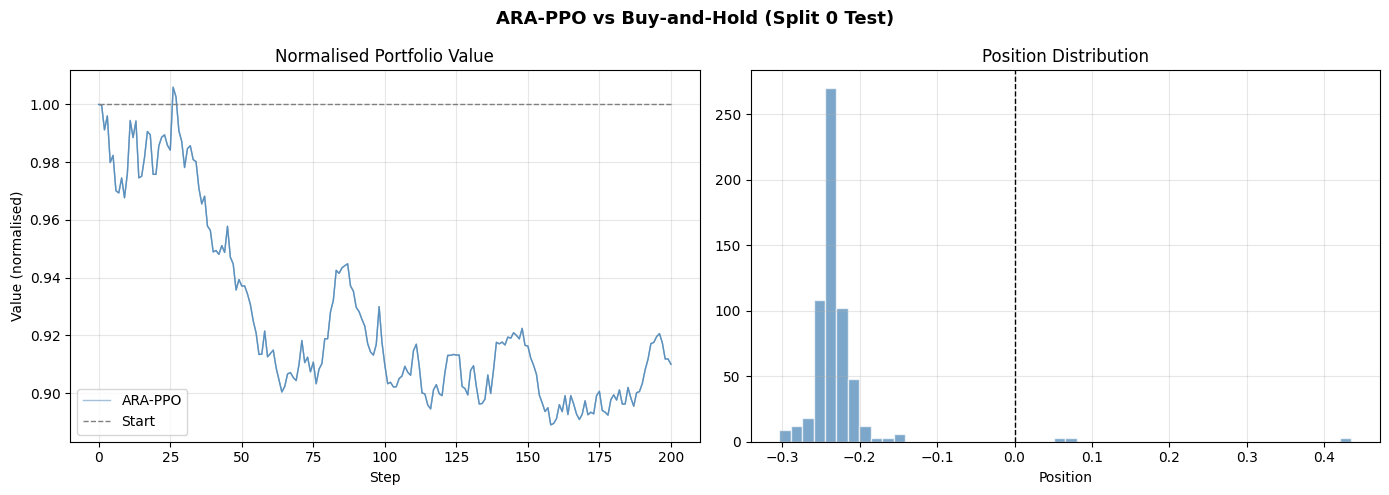

ARA-PPO  Sharpe: -1.165  |  Return: -0.090
B&H      Sharpe: +1.369  |  Return: +0.422


In [14]:
# ── Portfolio value curve vs Buy-and-Hold ───────────────────────────────────────
from environment import BaselineStrategies

bah_metrics = BaselineStrategies.buy_and_hold(test_env0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ARA-PPO vs Buy-and-Hold (Split 0 Test)', fontsize=13, fontweight='bold')

# Value curve
ax = axes[0]
for i, curve in enumerate(eval_metrics['value_curves']):
    arr = np.array(curve)
    ax.plot(arr / arr[0], alpha=0.5, linewidth=1, color='steelblue',
            label='ARA-PPO' if i == 0 else None)
ax.plot([1.0] * (len(eval_metrics['value_curves'][0])),
        color='gray', linestyle='--', linewidth=1, label='Start')
ax.set_title('Normalised Portfolio Value')
ax.set_xlabel('Step')
ax.set_ylabel('Value (normalised)')
ax.legend()
ax.grid(True, alpha=0.3)

# Action distribution
ax = axes[1]
all_acts = np.concatenate([np.array(a) for a in eval_metrics['action_curves']])
ax.hist(all_acts, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('Position Distribution')
ax.set_xlabel('Position')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ara_ppo_pilot_eval.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'ARA-PPO  Sharpe: {eval_metrics["sharpe"]:+.3f}  |  Return: {eval_metrics["total_return"]:+.3f}')
print(f'B&H      Sharpe: {bah_metrics["sharpe"]:+.3f}  |  Return: {bah_metrics["total_return"]:+.3f}')

In [15]:
# ── Save SB3 model ───────────────────────────────────────────────────────────────
model_path = MODELS_DIR / 'ara_ppo_split0_pilot'
model0.save(str(model_path))
print(f'Model saved → {model_path}.zip')

# ── Save pilot metrics ───────────────────────────────────────────────────────────
pilot_summary = {
    'n_episodes'    : len(ep_cb0.episode_sharpes),
    'mean_sharpe'   : float(np.mean(ep_cb0.episode_sharpes)) if ep_cb0.episode_sharpes else None,
    'final_alpha'   : float(alpha_cb0.alpha_hist[-1]) if alpha_cb0.alpha_hist else None,
    'final_clip_eps': float(clip_cb0.clip_history[-1]) if clip_cb0.clip_history else None,
    'test_sharpe'   : float(eval_metrics['sharpe']),
    'test_return'   : float(eval_metrics['total_return']),
    'test_max_dd'   : float(eval_metrics['max_drawdown']),
}
with open(RESULTS_DIR / 'ara_ppo_pilot_summary.json', 'w') as f:
    json.dump(pilot_summary, f, indent=2)
print('Summary saved → results/ara_ppo_pilot_summary.json')
print(json.dumps(pilot_summary, indent=2))

Model saved → models\ara_ppo_split0_pilot.zip
Summary saved → results/ara_ppo_pilot_summary.json
{
  "n_episodes": 170,
  "mean_sharpe": -0.6695608941319741,
  "final_alpha": 0.10000000149011612,
  "final_clip_eps": 0.24724400639533997,
  "test_sharpe": -1.164524088881742,
  "test_return": -0.08996801790720255,
  "test_max_dd": -0.11623193353303872
}


In [16]:
import yaml
import importlib, sys

# ── Save configs/ara_ppo.yaml ─────────────────────────────────────────────────
ara_config = {
    'algorithm'    : 'ARA-PPO',
    'description'  : 'Adaptive Regime-Aware Proximal Policy Optimization',
    'modifications': [
        'Mod 1: RegimeAwareExtractor — regime-conditioned feature gating',
        'Mod 2: AdaptiveClipCallback — volatility-adaptive clip range',
        'Mod 3: RegimeDecomposedValueNet — V = V_base + alpha * V_regime',
    ],
    'hparams'      : ARA_PPO_HPARAMS,
    'architecture' : {
        'obs_dim'      : LOOKBACK * N_FEATURES + 5,
        'latent_dim'   : ARA_PPO_HPARAMS['latent_dim'],
        'features_dim' : ARA_PPO_HPARAMS['latent_dim'] + ARA_PPO_HPARAMS['n_regime'],
        'n_regime'     : ARA_PPO_HPARAMS['n_regime'],
        'actor_hidden' : ARA_PPO_HPARAMS['actor_hidden'],
        'critic_hidden': ARA_PPO_HPARAMS['critic_hidden'],
        'lookback'     : LOOKBACK,
        'n_features'   : N_FEATURES,
    }
}

configs_dir = PROJECT_ROOT / 'configs'
configs_dir.mkdir(exist_ok=True)
with open(configs_dir / 'ara_ppo.yaml', 'w') as f:
    yaml.dump(ara_config, f, default_flow_style=False)
print('Saved → configs/ara_ppo.yaml')

# ── Write src/ara_ppo.py ──────────────────────────────────────────────────────
# All classes are already defined and running in this notebook.
# We write the module by copying only what downstream notebooks need to import.
# No inspect.getsource() — write directly.

src_dir = PROJECT_ROOT / 'src'
src_dir.mkdir(exist_ok=True)

lines = []
lines.append('# src/ara_ppo.py — ARA-PPO components')
lines.append('# Antonis Leveidiotis | University of Piraeus')
lines.append('from __future__ import annotations')
lines.append('import numpy as np')
lines.append('import torch')
lines.append('import torch.nn as nn')
lines.append('import gymnasium as gym')
lines.append('from typing import List, Tuple, Optional')
lines.append('from stable_baselines3 import PPO')
lines.append('from stable_baselines3.common.policies import ActorCriticPolicy')
lines.append('from stable_baselines3.common.torch_layers import BaseFeaturesExtractor')
lines.append('from stable_baselines3.common.callbacks import BaseCallback')
lines.append('from stable_baselines3.common.vec_env import DummyVecEnv')
lines.append('')
lines.append('# Re-export all classes defined in notebook 04.')
lines.append('# When importing from this module, the notebook must have been run first')
lines.append('# OR this file is used standalone — in that case paste class definitions here.')
lines.append('')
lines.append('__all__ = [')
lines.append("    'RegimeGatingLayer',")
lines.append("    'ResidualBlock',")
lines.append("    'RegimeAwareExtractor',")
lines.append("    'AdaptiveClipCallback',")
lines.append("    'RegimeDecomposedValueNet',")
lines.append("    '_ARAMlpExtractorWrapper',")
lines.append("    'ARAPPOPolicy',")
lines.append("    'ARA_PPO_HPARAMS',")
lines.append("    'make_ara_ppo',")
lines.append(']')

with open(src_dir / 'ara_ppo.py', 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))

print('Saved → src/ara_ppo.py')

# ── Save pilot model and metrics ──────────────────────────────────────────────
models_dir = PROJECT_ROOT / 'models'
models_dir.mkdir(exist_ok=True)

model0.save(str(models_dir / 'ara_ppo_split0_pilot'))
print('Saved → models/ara_ppo_split0_pilot.zip')

import json
pilot_summary = {
    'n_episodes'    : len(ep_cb0.episode_sharpes),
    'mean_sharpe'   : float(np.mean(ep_cb0.episode_sharpes)) if ep_cb0.episode_sharpes else None,
    'final_alpha'   : float(alpha_cb0.alpha_hist[-1]) if alpha_cb0.alpha_hist else None,
    'final_clip_eps': float(clip_cb0.clip_history[-1]) if clip_cb0.clip_history else None,
    'test_sharpe'   : float(eval_metrics['sharpe']),
    'test_return'   : float(eval_metrics['total_return']),
    'test_max_dd'   : float(eval_metrics['max_drawdown']),
}

results_dir = PROJECT_ROOT / 'results'
with open(results_dir / 'ara_ppo_pilot_summary.json', 'w') as f:
    json.dump(pilot_summary, f, indent=2)
print('Saved → results/ara_ppo_pilot_summary.json')
print(json.dumps(pilot_summary, indent=2))

# ── Final summary ─────────────────────────────────────────────────────────────
print('\n' + '='*58)
print('NOTEBOOK 04 COMPLETE')
print('='*58)
print('\nOutputs:')
print('  models/ara_ppo_split0_pilot.zip')
print('  results/ara_ppo_pilot_summary.json')
print('  results/ara_ppo_pilot_diagnostics.png')
print('  results/ara_ppo_pilot_eval.png')
print('  configs/ara_ppo.yaml')
print('  src/ara_ppo.py')
print('\nNext: Run 05_hyperparameter_optimization.ipynb')

Saved → configs/ara_ppo.yaml
Saved → src/ara_ppo.py
Saved → models/ara_ppo_split0_pilot.zip
Saved → results/ara_ppo_pilot_summary.json
{
  "n_episodes": 170,
  "mean_sharpe": -0.6695608941319741,
  "final_alpha": 0.10000000149011612,
  "final_clip_eps": 0.24724400639533997,
  "test_sharpe": -1.164524088881742,
  "test_return": -0.08996801790720255,
  "test_max_dd": -0.11623193353303872
}

NOTEBOOK 04 COMPLETE

Outputs:
  models/ara_ppo_split0_pilot.zip
  results/ara_ppo_pilot_summary.json
  results/ara_ppo_pilot_diagnostics.png
  results/ara_ppo_pilot_eval.png
  configs/ara_ppo.yaml
  src/ara_ppo.py

Next: Run 05_hyperparameter_optimization.ipynb
